
=== Quantile vs Bandwidth Evaluation ===

   quantile  bandwidth  n_clusters      S       CH     DB  composite
0      0.05     0.3719          22  0.391  190.144  0.663      0.305
1      0.10     0.6262           8  0.467  202.728  0.752      0.339
2      0.15     0.8777           5  0.534  219.783  0.584      0.396
3      0.20     1.0352           4  0.496  140.324  0.660      0.338
4      0.25     1.1372           2  0.368   61.960  0.893      0.219

Best quantile (by composite score):
quantile        0.1500
bandwidth       0.8777
n_clusters      5.0000
S               0.5340
CH            219.7830
DB              0.5840
composite       0.3960
Name: 2, dtype: float64


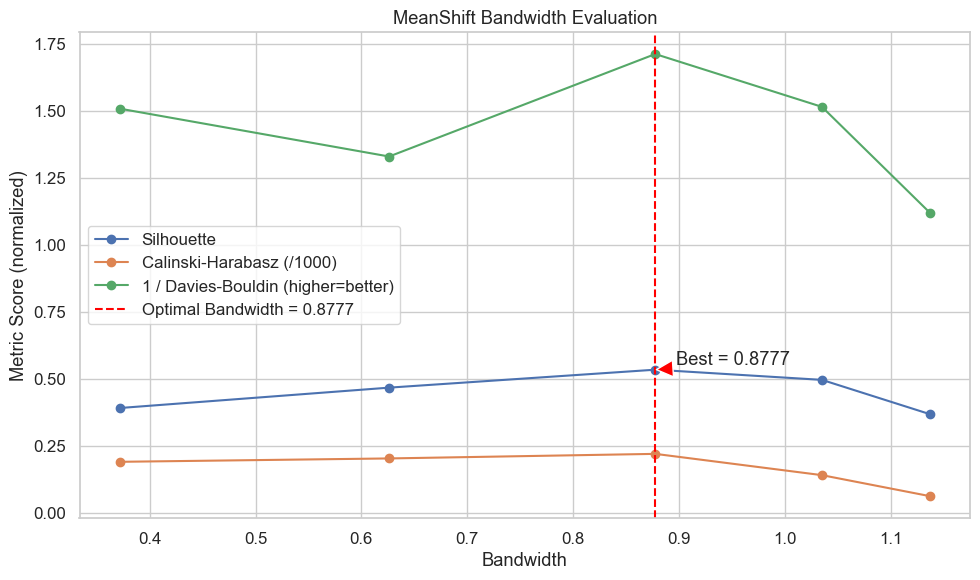

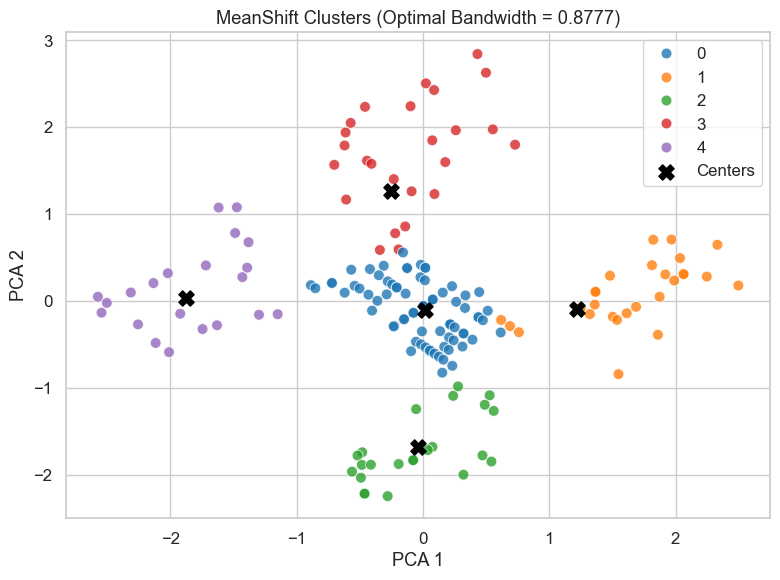

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Step: Define helper function
def evaluate_quantiles(X_scaled, quantiles=[0.05, 0.1, 0.15, 0.2, 0.25]):
    results = []

    for q in quantiles:
        # Estimate bandwidth for given quantile
        bw = estimate_bandwidth(X_scaled, quantile=q)

        # Fit MeanShift
        ms = MeanShift(bandwidth=bw)
        labels = ms.fit_predict(X_scaled)
        n_clusters = len(np.unique(labels))

        # Skip cases with only 1 cluster
        if n_clusters <= 1:
            results.append({
                'quantile': q,
                'bandwidth': bw,
                'n_clusters': n_clusters,
                'S': np.nan,
                'CH': np.nan,
                'DB': np.nan,
                'composite': np.nan
            })
            continue

        # Compute clustering metrics
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)

        # Composite score (higher = better)
        composite = (sil * 0.5) + (ch / 1000 * 0.4) + ((1 - db) * 0.1)

        results.append({
            'quantile': q,
            'bandwidth': round(bw, 4),
            'n_clusters': n_clusters,
            'S': round(sil, 3),
            'CH': round(ch, 3),
            'DB': round(db, 3),
            'composite': round(composite, 3)
        })

    return pd.DataFrame(results)

df = pd.read_csv("customer_data.csv")

df.drop(columns=['CustomerID', 'Gender', 'Age', 'Spending Score (1-100)', 'Mail id'], inplace=True)

WEIGHT_RFM = 0.8
WEIGHT_INCOME = 0.2

df['RFM Score'] = (
    (0.2 * (100 - df['Recency (days)'])) +
    (0.4 * df['Frequency (visits)']) +
    (0.4 * df['Monetary ($)'])
)

X = df[['RFM Score', 'Annual Income (k$)']].copy()
X['RFM Score'] *= WEIGHT_RFM
X['Annual Income (k$)'] *= WEIGHT_INCOME

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results_df = evaluate_quantiles(X_scaled, quantiles=[0.05, 0.1, 0.15, 0.2, 0.25])

print("\n=== Quantile vs Bandwidth Evaluation ===\n")
print(results_df[['quantile', 'bandwidth', 'n_clusters', 'S', 'CH', 'DB', 'composite']])
print("\nBest quantile (by composite score):")
print(results_df.loc[results_df['composite'].idxmax()])

sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(10, 6))

plt.plot(results_df['bandwidth'], results_df['S'], marker='o', label='Silhouette')
plt.plot(results_df['bandwidth'], results_df['CH'] / 1000, marker='o', label='Calinski-Harabasz (/1000)')
plt.plot(results_df['bandwidth'], 1 / results_df['DB'], marker='o', label='1 / Davies-Bouldin (higher=better)')

best_idx = results_df['composite'].idxmax()
best_bw = results_df.loc[best_idx, 'bandwidth']

plt.axvline(best_bw, color='red', linestyle='--', label=f'Optimal Bandwidth = {best_bw}')
plt.title("MeanShift Bandwidth Evaluation")
plt.xlabel("Bandwidth")
plt.ylabel("Metric Score (normalized)")
plt.legend()
plt.tight_layout()

plt.annotate(f'Best = {best_bw}', xy=(best_bw, results_df.loc[best_idx, 'S']),
             xytext=(best_bw + 0.02, results_df.loc[best_idx, 'S'] + 0.02),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

best_bw = results_df.loc[results_df['composite'].idxmax(), 'bandwidth']

ms_best = MeanShift(bandwidth=best_bw)
labels_best = ms_best.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", len(np.unique(labels_best)))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=labels_best, palette=palette, s=60, alpha=0.8
)
plt.title(f"MeanShift Clusters (Optimal Bandwidth = {best_bw})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Mark cluster centers
centers_pca = pca.transform(ms_best.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', s=120, marker='X', label='Centers')

plt.legend()
plt.tight_layout()
plt.show()

Number of clusters formed: 5

Silhouette: 0.534, Calinski-Harabasz: 219.783, Davies-Bouldin: 0.584


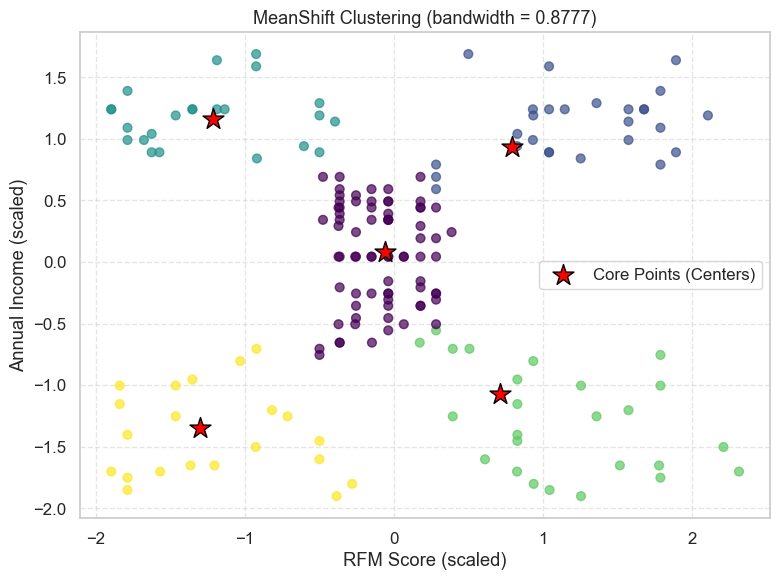

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

df = pd.read_csv("customer_data.csv")

df.drop(columns=['CustomerID', 'Gender', 'Age', 'Spending Score (1-100)', 'Mail id'], inplace=True)

# Define weights
WEIGHT_RFM = 0.8
WEIGHT_INCOME = 0.2


df['RFM Score'] = (
    (0.2 * (100 - df['Recency (days)'])) +
    (0.4 * df['Frequency (visits)']) +
    (0.4 * df['Monetary ($)'])
)

X = df[['RFM Score', 'Annual Income (k$)']].copy()
X['RFM Score'] *= WEIGHT_RFM
X['Annual Income (k$)'] *= WEIGHT_INCOME

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

best_bandwidth = 0.8777  # from previous quantile analysis
ms = MeanShift(bandwidth=best_bandwidth)
labels = ms.fit_predict(X_scaled)
centers = ms.cluster_centers_

n_clusters = len(np.unique(labels))
print(f"Number of clusters formed: {n_clusters}")

S = silhouette_score(X_scaled, labels)
CH = calinski_harabasz_score(X_scaled, labels)
DB = davies_bouldin_score(X_scaled, labels)
print(f"\nSilhouette: {S:.3f}, Calinski-Harabasz: {CH:.3f}, Davies-Bouldin: {DB:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=40, alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='*', edgecolors='black', label='Core Points (Centers)')

plt.title(f"MeanShift Clustering (bandwidth = {best_bandwidth})", fontsize=13)
plt.xlabel("RFM Score (scaled)")
plt.ylabel("Annual Income (scaled)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()